Create Database

In [1]:
import os, re, warnings
import pandas as pd
import sqlite3
import os
import json
from typing import Annotated, TypedDict
from openai import OpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
import plotly.express as px
import plotly.graph_objects as go

data_path = "inputs"

db = "ecommerce.db"
if os.path.exists(db):
    os.remove(db)

conn = sqlite3.connect(db)

def load(name):
    df = pd.read_csv(f"{data_path}/{name}")
    table_name = name.replace("olist_", "").replace("_dataset.csv", "").replace(".csv", "")
    df.to_sql(table_name, conn, index=False, if_exists="replace")
    print(f"Loaded: {name} -> {table_name} table ({df.shape[0]} rows, {df.shape[1]} columns)")

load("olist_customers_dataset.csv")
load("olist_orders_dataset.csv")
load("olist_order_items_dataset.csv")
load("olist_order_payments_dataset.csv")
load("olist_order_reviews_dataset.csv")
load("olist_products_dataset.csv")
load("olist_sellers_dataset.csv")
load("olist_geolocation_dataset.csv")
load("product_category_name_translation.csv")

conn.close()
print(f"\nDatabase created: {db}")
print("Tables: customers, orders, order_items, order_payments, order_reviews, products, sellers, geolocation, product_category_name_translation")

/home/srikanth/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/srikanth/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loaded: olist_customers_dataset.csv -> customers table (99441 rows, 5 columns)
Loaded: olist_orders_dataset.csv -> orders table (99441 rows, 8 columns)
Loaded: olist_order_items_dataset.csv -> order_items table (112650 rows, 7 columns)
Loaded: olist_order_payments_dataset.csv -> order_payments table (103886 rows, 5 columns)
Loaded: olist_order_reviews_dataset.csv -> order_reviews table (99224 rows, 7 columns)
Loaded: olist_products_dataset.csv -> products table (32951 rows, 9 columns)
Loaded: olist_sellers_dataset.csv -> sellers table (3095 rows, 4 columns)
Loaded: olist_geolocation_dataset.csv -> geolocation table (1000163 rows, 5 columns)
Loaded: product_category_name_translation.csv -> product_category_name_translation table (71 rows, 2 columns)

Database created: ecommerce.db
Tables: customers, orders, order_items, order_payments, order_reviews, products, sellers, geolocation, product_category_name_translation


Configuration and Setup

In [2]:
load_dotenv()
client = OpenAI(
    api_key=os.environ.get("OPENROUTER_API_KEY", "Enter API Key"),
    base_url="https://openrouter.ai/api/v1",
)
MODEL_NAME = "google/gemini-2.0-flash-001"
# Database configuration
DB_PATH = "ecommerce.db"

Database Schema Information

In [3]:
SCHEMA_INFO = """
Database Schema for E-commerce System:

1. customers
   - customer_id (TEXT): Unique customer identifier
   - customer_unique_id (TEXT): Unique customer identifier across datasets
   - customer_zip_code_prefix (INTEGER): Customer zip code
   - customer_city (TEXT): Customer city
   - customer_state (TEXT): Customer state

2. orders
   - order_id (TEXT): Unique order identifier
   - customer_id (TEXT): Foreign key to customers
   - order_status (TEXT): Order status (delivered, shipped, etc.)
   - order_purchase_timestamp (TEXT): When the order was placed
   - order_approved_at (TEXT): When payment was approved
   - order_delivered_carrier_date (TEXT): When order was handed to carrier
   - order_delivered_customer_date (TEXT): When customer received the order
   - order_estimated_delivery_date (TEXT): Estimated delivery date

3. order_items
   - order_id (TEXT): Foreign key to orders
   - order_item_id (INTEGER): Item sequence number within order
   - product_id (TEXT): Foreign key to products
   - seller_id (TEXT): Foreign key to sellers
   - shipping_limit_date (TEXT): Shipping deadline
   - price (REAL): Item price
   - freight_value (REAL): Shipping cost

4. order_payments
   - order_id (TEXT): Foreign key to orders
   - payment_sequential (INTEGER): Payment sequence number
   - payment_type (TEXT): Payment method (credit_card, boleto, etc.)
   - payment_installments (INTEGER): Number of installments
   - payment_value (REAL): Payment amount

5. order_reviews
   - review_id (TEXT): Unique review identifier
   - order_id (TEXT): Foreign key to orders
   - review_score (INTEGER): Review score (1-5)
   - review_comment_title (TEXT): Review title
   - review_comment_message (TEXT): Review message
   - review_creation_date (TEXT): When review was created
   - review_answer_timestamp (TEXT): When review was answered

6. products
   - product_id (TEXT): Unique product identifier
   - product_category_name (TEXT): Product category (in Portuguese)
   - product_name_lenght (REAL): Product name length
   - product_description_lenght (REAL): Product description length
   - product_photos_qty (REAL): Number of product photos
   - product_weight_g (REAL): Product weight in grams
   - product_length_cm (REAL): Product length in cm
   - product_height_cm (REAL): Product height in cm
   - product_width_cm (REAL): Product width in cm

7. sellers
   - seller_id (TEXT): Unique seller identifier
   - seller_zip_code_prefix (INTEGER): Seller zip code
   - seller_city (TEXT): Seller city
   - seller_state (TEXT): Seller state

8. geolocation
   - geolocation_zip_code_prefix (INTEGER): Zip code prefix
   - geolocation_lat (REAL): Latitude
   - geolocation_lng (REAL): Longitude
   - geolocation_city (TEXT): City name
   - geolocation_state (TEXT): State code

9. product_category_name_translation
   - product_category_name (TEXT): Category name in Portuguese
   - product_category_name_english (TEXT): Category name in English
"""

State Definition

In [4]:
class AgentState(TypedDict):
    """State of the agent workflow"""
    question: str
    sql_query: str
    query_result: str
    final_answer: str
    error: str
    iteration: int
    needs_graph: bool
    graph_type: str
    graph_json: str  # Plotly figure JSON for Chainlit
    is_in_scope: bool  # Whether the question is about e-commerce data

Agent Configurations

In [5]:
AGENT_CONFIGS = {
    "guardrails_agent": {
        "role": "Security and Scope Manager",
        "system_prompt": "You are a strict guardrails system that filters questions to ensure they are relevant to e-commerce data analysis or identifies greetings.",
    },
    "sql_agent": {
        "role": "SQL Expert", 
        "system_prompt": "You are a senior SQL developer specializing in e-commerce databases. Generate only valid SQLite queries without any formatting or explanation.",
    },
    "analysis_agent": {
        "role": "Data Analyst",
        "system_prompt": "You are a helpful data analyst that explains database query results in natural language with clear insights.",
    },
    "viz_agent": {
        "role": "Visualization Specialist", 
        "system_prompt": "You are a data visualization expert. Generate clean, executable Plotly code without any markdown formatting or explanations.",
    },
    "error_agent": {
        "role": "Error Recovery Specialist",
        "system_prompt": "You diagnose and fix SQL errors with expert knowledge of database schemas and query optimization.",
    }
}

Node Functionality

In [6]:
## Guadrial Agent
def guardrails_agent(state: AgentState) -> AgentState:
    """Check if the question is within scope (e-commerce related)"""
    question = state["question"]
    
    prompt = f"""You are a guardrails system for an e-commerce database chatbot. Your job is to determine if a user's question is related to e-commerce data, if it's a greeting, or if it's out of scope.

The chatbot has access to an e-commerce database with information about:
- Customers and their locations
- Orders and order status (data from 2016-2018)
- Products and categories
- Sellers
- Payments
- Reviews
- Shipping and delivery information

Examples of GREETING messages:
- "Hi", "Hello", "Hey"
- "Good morning", "Good afternoon"
- "How are you?"
- Any casual greeting or introduction

Examples of IN-SCOPE questions:
- "How many orders were placed last month?"
- "What are the top selling products?"
- "Show me customer distribution by state"
- "What is the average order value?"
- "Which sellers have the highest ratings?"

Examples of OUT-OF-SCOPE questions:
- Personal questions (e.g., "What is my wife's name?", "Where do I live?")
- Political questions (e.g., "Who should I vote for?", "What do you think about the president?")
- General knowledge (e.g., "What is the capital of France?", "How does photosynthesis work?")
- Unrelated topics (e.g., "Tell me a joke", "What's the weather like?")

User Question: {question}

Analyze the question and respond in JSON format:
{{
    "is_in_scope": true/false,
    "is_greeting": true/false,
    "reason": "brief explanation of why it is or isn't in scope or if it's a greeting"
}}

If the question is a greeting, mark is_greeting as true and is_in_scope as false.
If the question is ambiguous but could potentially relate to the e-commerce data, mark it as in_scope."""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": AGENT_CONFIGS["guardrails_agent"]["system_prompt"]},
            {"role": "user", "content": prompt}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    
    result = json.loads(response.choices[0].message.content)
    state["is_in_scope"] = result.get("is_in_scope", False)
    is_greeting = result.get("is_greeting", False)
    
    # If it's a greeting, provide a welcome message
    if is_greeting:
        state["final_answer"] = "Hi! I am your e-commerce assistant. I can answer all the queries related to orders, customers, products, sellers, payments, and reviews between 2016-2018. How can I help you today?"
        return state
    
    # If out of scope, set the final answer immediately
    if not state["is_in_scope"]:
        state["final_answer"] = "I apologize, but your question appears to be out of scope. I can only answer questions about the e-commerce data, including:\n\n- Customer information and locations\n- Orders and order status\n- Products and categories\n- Sellers and their performance\n- Payment information\n- Reviews and ratings\n- Shipping and delivery data\n\nPlease ask a question related to the e-commerce database."
    
    return state

## SQL Agent
def sql_agent(state: AgentState) -> AgentState:
    """Generate SQL query from natural language question"""
    question = state["question"]
    iteration = state.get("iteration", 0)
    
    prompt = f"""You are a SQL expert. Convert the following natural language question into a valid SQLite query.

{SCHEMA_INFO}

Question: {question}

Important Guidelines:
1. Use only the tables and columns mentioned in the schema
2. Use proper JOIN clauses when querying multiple tables
3. Return ONLY the SQL query without any explanation or markdown formatting
4. If the question contains multiple sub-questions, generate separate SQL queries separated by semicolons
5. Use aggregate functions (COUNT, SUM, AVG, etc.) appropriately
6. Add LIMIT clauses for queries that might return many rows (default LIMIT 10 unless user specifies)
7. Use proper WHERE clauses to filter data
8. For date comparisons, remember the dates are stored as TEXT in ISO format
9. Each SQL statement should be on its own line for clarity when multiple queries are needed

Generate the SQL query:"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": AGENT_CONFIGS["sql_agent"]["system_prompt"]},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )
    
    sql_query = response.choices[0].message.content.strip()
    # Remove markdown code blocks if present
    sql_query = sql_query.replace("```sql", "").replace("```", "").strip()
    
    state["sql_query"] = sql_query
    state["iteration"] = iteration + 1
    
    return state

##Execute Agent
def execute_sql(state: AgentState) -> AgentState:
    """Execute the generated SQL query (handles multiple queries if present)"""
    sql_query = state["sql_query"]
    
    try:
        conn = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()
        
        # Split multiple SQL statements (separated by semicolons)
        # Remove empty statements and strip whitespace
        sql_statements = [stmt.strip() for stmt in sql_query.split(';') if stmt.strip()]
        
        all_results = []
        
        # Execute each statement separately
        for i, statement in enumerate(sql_statements):
            cursor.execute(statement)
            
            # Fetch results for this statement
            results = cursor.fetchall()
            
            if results:
                column_names = [description[0] for description in cursor.description]
                
                # Convert to list of dictionaries
                formatted_results = []
                for row in results[:100]:  # Limit to 100 rows per query
                    formatted_results.append(dict(zip(column_names, row)))
                
                # If multiple queries, label them
                if len(sql_statements) > 1:
                    all_results.append({
                        f"query_{i+1}": formatted_results,
                        f"query_{i+1}_sql": statement
                    })
                else:
                    all_results = formatted_results
        
        conn.close()
        
        #  Format results
        if not all_results:
            state["query_result"] = "No results found."
        else:
            state["query_result"] = json.dumps(all_results, indent=2)
        
        state["error"] = ""
        
    except Exception as e:
        state["error"] = f"SQL Execution Error: {str(e)}"
        state["query_result"] = ""
    
    return state

##Error Agent
def error_agent(state: AgentState) -> AgentState:
    """Handle errors and attempt to fix the SQL query"""
    error = state["error"]
    sql_query = state["sql_query"]
    question = state["question"]
    iteration = state.get("iteration", 0)
    
    # If we've tried too many times, give up
    if iteration > 3:
        state["final_answer"] = f"I apologize, but I'm having trouble generating a correct SQL query for your question. Error: {error}"
        return state
    
    prompt = f"""The following SQL query failed with an error. Please fix it.

{SCHEMA_INFO}

Original Question: {question}

Failed SQL Query: {sql_query}

Error: {error}

Generate a corrected SQL query that will work. Return ONLY the SQL query without any explanation or markdown formatting:"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": AGENT_CONFIGS["error_agent"]["system_prompt"]},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )
    
    corrected_query = response.choices[0].message.content.strip()
    corrected_query = corrected_query.replace("```sql", "").replace("```", "").strip()
    
    state["sql_query"] = corrected_query
    state["error"] = ""  # Clear the error for retry
    state["iteration"] = iteration + 1  # Increment iteration counter
    
    return state

## Analysis Agent
def analysis_agent(state: AgentState) -> AgentState:
    """Generate natural language answer from query results"""
    question = state["question"]
    sql_query = state["sql_query"]
    query_result = state["query_result"]
    
    prompt = f"""You are a helpful assistant that explains database query results in natural language.

Original Question: {question}

SQL Query Used: {sql_query}

Query Results:
{query_result}

Please provide a clear, concise answer to the original question based on the query results.
Format the answer in a user-friendly way. If the results contain numbers, present them clearly.
If there are multiple queries/results (for multi-part questions), address each part of the question separately.
Use bullet points or numbered lists for multiple answers.

Answer:"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": AGENT_CONFIGS["analysis_agent"]["system_prompt"]},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7
    )
    
    final_answer = response.choices[0].message.content.strip()
    state["final_answer"] = final_answer
    
    return state

def decide_graph_need(state: AgentState) -> AgentState:
    """Decide if a graph visualization would be helpful for the query"""
    question = state["question"]
    query_result = state["query_result"]
    
    # If no results or error, no graph needed
    if not query_result or query_result == "No results found." or state.get("error"):
        state["needs_graph"] = False
        state["graph_type"] = ""
        return state
    
    prompt = f"""Analyze the following question and query results to determine if a graph visualization would be helpful.

Question: {question}

Query Results Sample:
{query_result[:500]}...

Determine:
1. Would a graph be helpful for this data? (YES/NO)
2. If yes, what type of graph? (bar, line, pie, scatter)

Consider:
- Trends over time → line chart
- Comparisons between categories → bar chart
- Proportions/percentages → pie chart
- Correlations → scatter plot
- Simple counts or single values → NO graph needed

Respond in JSON format:
{{"needs_graph": true/false, "graph_type": "bar/line/pie/scatter/none", "reason": "brief explanation"}}
"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": "You are a data visualization expert. Analyze queries and determine if visualization would add value."},
            {"role": "user", "content": prompt}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    
    decision = json.loads(response.choices[0].message.content)
    state["needs_graph"] = decision.get("needs_graph", False)
    state["graph_type"] = decision.get("graph_type", "none")
    
    return state

## visualisation Agent
def viz_agent(state: AgentState) -> AgentState:
    """
    Generates a Plotly visualization from query results.
    Includes robust data reshaping for single-column SQL results 
    and sanitization to prevent 'unexpected indent' errors in exec().
    """
    query_result = state.get("query_result")
    graph_type = state.get("graph_type", "bar")
    question = state.get("question")
    
    if not query_result or query_result == "No results found.":
        state["graph_json"] = ""
        return state

    try:
        # 1. Load Data
        results = json.loads(query_result)
        df = pd.DataFrame(results)

        # 2. DATA RESHAPING FALLBACK
        # If SQL only returned 1 column (e.g., just names), the graph will fail.
        # We automatically calculate counts so the Y-axis has data.
        if len(df.columns) == 1:
            col_name = df.columns[0]
            df = df[col_name].value_counts().reset_index()
            df.columns = [col_name, 'count']

        columns = df.columns.tolist()
        sample_data = df.head(3).to_dict('records')
        
        # 3. STRICT PROMPT
        prompt = f"""Generate Python code using Plotly Express (px) to visualize this data.
DataFrame name: 'df'
Question: {question}
Graph Type: {graph_type}
Columns: {columns}
Sample Data: {json.dumps(sample_data)}

Requirements:
1. Use plotly.graph_objects or plotly.express
2. The data is already loaded as 'df' (a pandas DataFrame)
3. Create an appropriate {graph_type} chart
4. Limit data to top 20 rows if there are many rows
5. Add proper titles, labels, and formatting
6. The figure variable must be named 'fig'
7. Return ONLY the Python code, no explanations or markdown
8. Do NOT include any import statements
9. Do NOT include code to show the figure (no fig.show())
10. Make the visualization visually appealing with appropriate colors and layout
11. Update the layout for better interactivity (hover info, responsive sizing).
"""

        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1
        )
        
        # 4. SANITIZATION (Enhanced)
        raw_output = response.choices[0].message.content.strip()
        
        # Clean markdown and common LLM filler
        if "```" in raw_output:
            raw_output = raw_output.split("```")[-1].replace("python", "").strip()
        
        # Filter out non-code lines (like "Question:" or "Answer:")
        lines = raw_output.split('\n')
        code_lines = []
        for line in lines:
            # Skip empty lines, imports, or common conversational markers
            clean = line.strip()
            if not clean or clean.startswith(('import', 'from', 'Question:', 'Answer:', 'Here is')):
                continue
            code_lines.append(line)
        
        plotly_code = "\n".join(code_lines)

       
        exec_globals = {
            'df': df,
            'pd': pd,
            'px': px,
            'go': go,
            'fig': None
        }
        
        # Execute
        exec(plotly_code, exec_globals)
        
        fig = exec_globals.get('fig')
        if fig:
            state["graph_json"] = fig.to_json()
        else:
            # Fallback: Check if the LLM just wrote the code without 'fig ='
            raise ValueError("The LLM code did not assign 'fig'.")
        
    except Exception as e:
        print(f"Viz Agent Error: {e}")
        print(f"Code Attempted:\n{plotly_code if 'plotly_code' in locals() else 'None'}")
        state["graph_json"] = ""
    
    return state

## conditional logic ---> control the workflow routing into the langgraph based on the question type and error handling
def should_retry(state: AgentState) -> str:
    """Decide whether to retry after an error"""
    if state.get("error"):
        iteration = state.get("iteration", 0)
        if iteration <= 3:
            return "retry"
        else:
            return "end"
    return "success"
def should_generate_graph(state: AgentState) -> str:
    """Decide whether to generate a graph"""
    if state.get("needs_graph", False):
        return "viz_agent"
    return "skip_graph"
def check_scope(state: AgentState) -> str:
    """Check if question is in scope to continue processing"""
    if state.get("is_in_scope", True):
        return "in_scope"
    return "out_of_scope"


Build the langgraph workflow

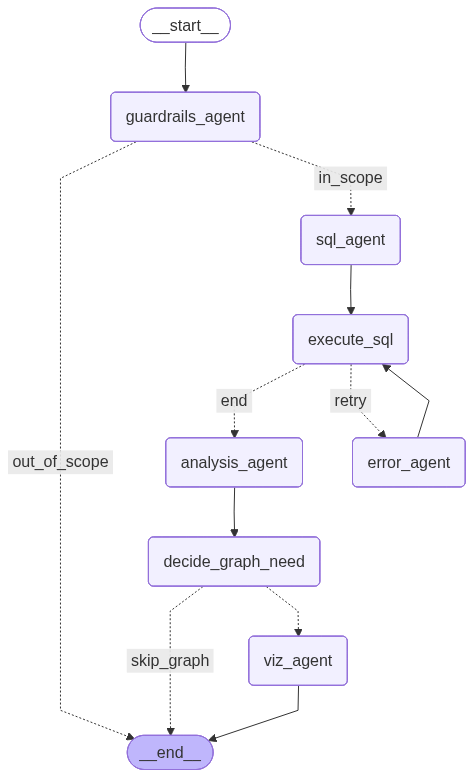

In [7]:
def create_text2sql_graph():
    """Create the LangGraph state graph for Text2SQL with graph generation"""
    
    workflow = StateGraph(AgentState)
    
    # Add nodes
    workflow.add_node("guardrails_agent", guardrails_agent)
    workflow.add_node("sql_agent", sql_agent)
    workflow.add_node("execute_sql", execute_sql)
    workflow.add_node("analysis_agent", analysis_agent)
    workflow.add_node("error_agent", error_agent)
    workflow.add_node("decide_graph_need", decide_graph_need)
    workflow.add_node("viz_agent", viz_agent)
    
    # Add edges - start with guardrails check
    workflow.set_entry_point("guardrails_agent")
    
    # Conditional edge from guardrails - only proceed if in scope
    workflow.add_conditional_edges(
        "guardrails_agent",
        check_scope,
        {
            "in_scope": "sql_agent",
            "out_of_scope": END
        }
    )
    
    workflow.add_edge("sql_agent", "execute_sql")
    
    # Conditional edge based on execution success
    workflow.add_conditional_edges(
        "execute_sql",
        should_retry,
        {
            "success": "analysis_agent",
            "retry": "error_agent",
            "end": "analysis_agent"
        }
    )
    
    workflow.add_edge("error_agent", "execute_sql")
    workflow.add_edge("analysis_agent", "decide_graph_need")
     # Conditional edge for graph generation
    workflow.add_conditional_edges(
        "decide_graph_need",
        should_generate_graph,
        {
            "viz_agent": "viz_agent",
            "skip_graph": END
        }
    )
    
    workflow.add_edge("viz_agent", END)
    
    return workflow.compile()

text2sql_graph = create_text2sql_graph()

## visualize the graph
from IPython.display import Image,display

try:
    display(Image(text2sql_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

In [8]:
def process_question(question: str) -> dict:
    """
    Process a natural language question and return the final result.
    This is a simple synchronous function for notebook usage.
    
    Args:
        question: Natural language question about the e-commerce data
        
    Returns:
        dict: Final state with answer, SQL query, and graph data if applicable
    """
    initial_state = AgentState(
        question=question,
        sql_query="",
        query_result="",
        final_answer="",
        error="",
        iteration=0,
        needs_graph=False,
        graph_type="",
        graph_json="",
        is_in_scope=True
    )
    
    try:
        # Invoke the graph
        final_state = text2sql_graph.invoke(
            initial_state,
            config={"recursion_limit": 50}
        )
        
        return final_state
        
    except Exception as e:
        return {
            "error": str(e),
            "final_answer": f"An error occurred while processing your question: {str(e)}"
        }

Testing the agent

In [9]:
result = process_question("Hello!")
print(f"Answer: {result['final_answer']}")

Answer: Hi! I am your e-commerce assistant. I can answer all the queries related to orders, customers, products, sellers, payments, and reviews between 2016-2018. How can I help you today?


In [10]:
my_question = "What are the most popular payment methods along with their counts?"

result = process_question(my_question)
print(f"Question: {my_question}")
print(f"\nAnswer: {result['final_answer']}")
print(f"\nSQL Query: {result.get('sql_query', 'N/A')}")

# Display graph if available
if result.get('graph_json'):
    import plotly.io as pio
    fig = pio.from_json(result['graph_json'])
    fig.show()

Viz Agent Error: The LLM code did not assign 'fig'.
Code Attempted:

Question: What are the most popular payment methods along with their counts?

Answer: The most popular payment methods are:

*   **Credit Card:** Used in 76,795 transactions.
*   **Boleto:** Used in 19,784 transactions.
*   **Voucher:** Used in 5,775 transactions.
*   **Debit Card:** Used in 1,529 transactions.
*   **Not Defined:** Used in 3 transactions.

SQL Query: SELECT payment_type, COUNT(*) AS payment_count FROM order_payments GROUP BY payment_type ORDER BY payment_count DESC LIMIT 10;


In [11]:
result = process_question("Recommend me a movie to watch tonight based on my mood.")
print(f"Answer: {result['final_answer']}")

Answer: I apologize, but your question appears to be out of scope. I can only answer questions about the e-commerce data, including:

- Customer information and locations
- Orders and order status
- Products and categories
- Sellers and their performance
- Payment information
- Reviews and ratings
- Shipping and delivery data

Please ask a question related to the e-commerce database.
